In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [ ]:
df = pd.read_csv("custom_learning_data_1000.csv")
X = df[['score','time_taken','reattempts','topic_errors','avg_difficulty','consistency']]
y = df['level']

<bound method DataFrame.sum of      score  time_taken  reattempts  topic_errors  avg_difficulty  consistency  \
0    False       False       False         False           False        False   
1    False       False       False         False           False        False   
2    False       False       False         False           False        False   
3    False       False       False         False           False        False   
4    False       False       False         False           False        False   
..     ...         ...         ...           ...             ...          ...   
995  False       False       False         False           False        False   
996  False       False       False         False           False        False   
997  False       False       False         False           False        False   
998  False       False       False         False           False        False   
999  False       False       False         False           False        False 

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, dt_pred))


rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.995
Accuracy: 1.0


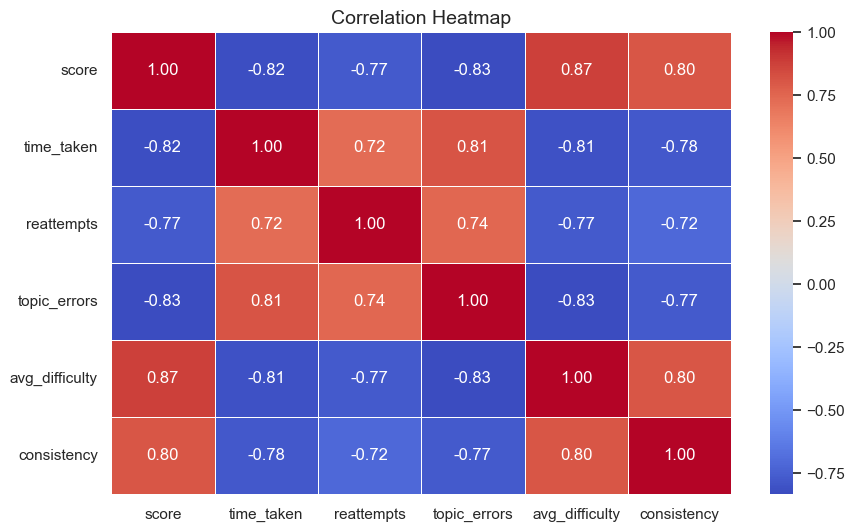

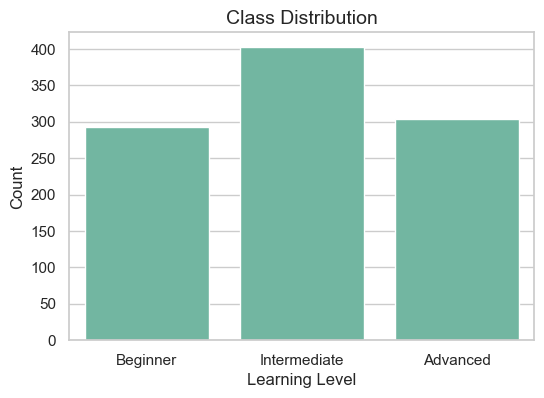

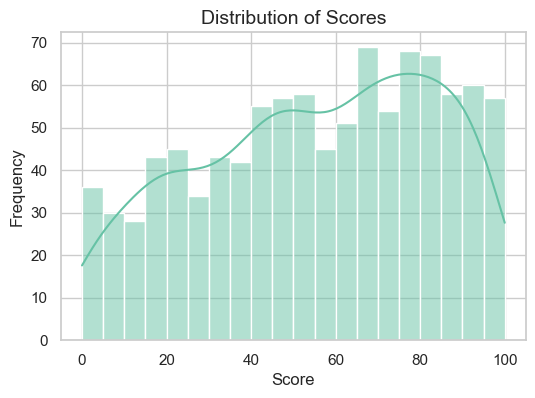

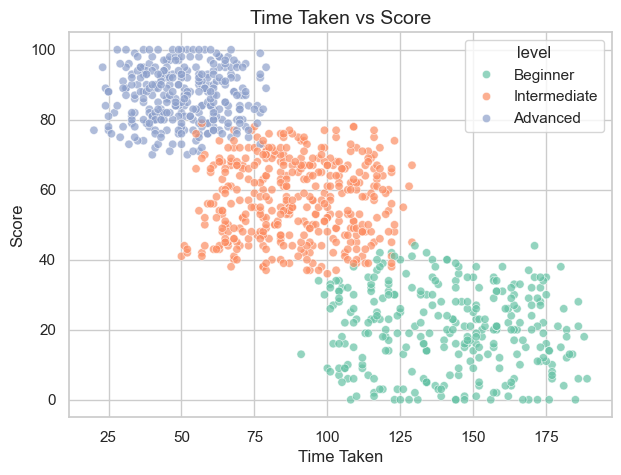

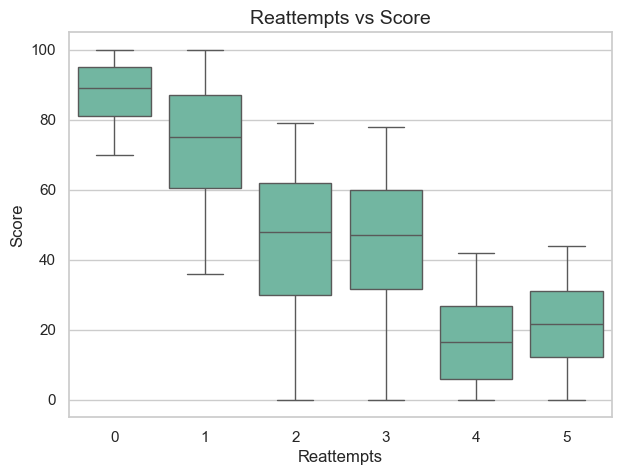

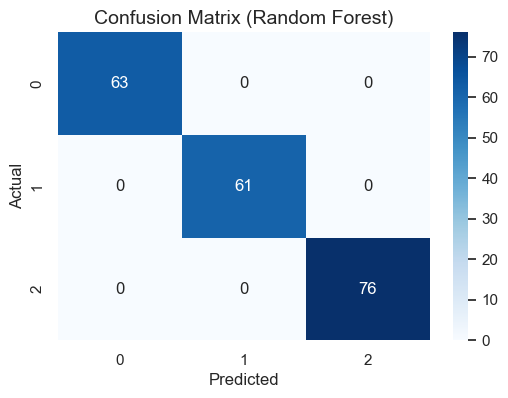

C:\Users\Aarsh\AppData\Local\Temp\ipykernel_10892\2942833745.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


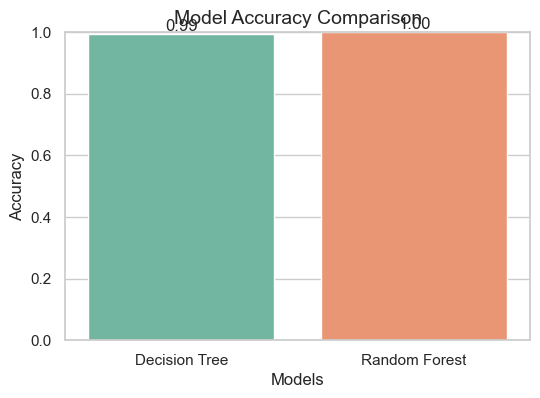

In [8]:

sns.set(style="whitegrid", palette="Set2")
plt.rcParams['figure.facecolor'] = 'white'

# 1. HEATMAP
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap", fontsize=14)
plt.show()


# 2. CLASS DISTRIBUTION
plt.figure(figsize=(6,4))
sns.countplot(x='level', data=df)
plt.title("Class Distribution", fontsize=14)
plt.xlabel("Learning Level")
plt.ylabel("Count")
plt.show()


# 3. SCORE DISTRIBUTION (REPLACED G3)
plt.figure(figsize=(6,4))
sns.histplot(df['score'], bins=20, kde=True)
plt.title("Distribution of Scores", fontsize=14)
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


# 4. TIME TAKEN vs SCORE
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='time_taken',
    y='score',
    data=df,
    hue='level',
    palette='Set2',
    alpha=0.7
)
plt.title("Time Taken vs Score", fontsize=14)
plt.xlabel("Time Taken")
plt.ylabel("Score")
plt.show()

# 5. REATTEMPTS vs SCORE

plt.figure(figsize=(7,5))
sns.boxplot(x='reattempts', y='score', data=df)
plt.title("Reattempts vs Score", fontsize=14)
plt.xlabel("Reattempts")
plt.ylabel("Score")
plt.show()

# CONFUSION MATRIX
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest)", fontsize=14)
plt.show()

# MODEL ACCURACY BAR GRAPH
models = ['Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]
plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracies, palette='Set2')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.ylim(0,1)

plt.show()


In [9]:
joblib.dump(rf_model, "decision_tree_model.pkl")

['decision_tree_model.pkl']